In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from tqdm import tqdm
tqdm.pandas()
from dateutil.relativedelta import relativedelta
pd.set_option("display.max_columns", None)
from dateutil.relativedelta import relativedelta
from itertools import accumulate

from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

import prince

# Date format = "%Y-%m-%d" @ datetime type

In [2]:
input_folder_path = rf"..\[1] Director Level\director_wrangle_output"
output_folder_path = "director_skills_pca"
supporting_folder_path = "supporting_datafiles"

In [4]:
mainDirect = pd.read_pickle(rf"{input_folder_path}\Main_Director_PCA filtered.pkl")

In [3]:
cols =  [
 'skilllist_sustainability',
 'skilllist_entrepreneurial',
 'skilllist_compensation',
 'skilllist_conglomerate_experience',
 'skilllist_hr',
 'skilllist_technology',
 'skilllist_finance_accounting',
 'skilllist_governance',
 'skilllist_government_policy',
 'skilllist_international',
 'skilllist_leadership',
 'skilllist_legal',
 'skilllist_marketing',
 'skilllist_risk_management',
 'skilllist_scientific',
 'skilllist_strategic_planning',
 'skilllist_manufacturing_supply_chain',
 'profile_sustainability',
 'profile_entrepreneurial',
 'profile_compensation',
 'profile_conglomerate_experience',
 'profile_hr',
 'profile_technology',
 'profile_finance_accounting',
 'profile_governance',
 'profile_government_policy',
 'profile_international',
 'profile_leadership',
 'profile_legal',
 'profile_marketing',
 'profile_risk_management',
 'profile_scientific',
 'profile_strategic_planning',
 'profile_manufacturing_supply_chain',
 'committee_sustainability',
 'committee_entrepreneurial',
 'committee_compensation',
 'committee_conglomerate_experience',
 'committee_hr',
 'committee_technology',
 'committee_finance_accounting',
 'committee_governance',
 'committee_government_policy',
 'committee_international',
 'committee_leadership',
 'committee_legal',
 'committee_marketing',
 'committee_risk_management',
 'committee_scientific',
 'committee_strategic_planning',
 'committee_manufacturing_supply_chain',
 'combined_sustainability',
 'combined_entrepreneurial',
 'combined_compensation',
 'combined_conglomerate_experience',
 'combined_hr',
 'combined_technology',
 'combined_finance_accounting',
 'combined_governance',
 'combined_government_policy',
 'combined_international',
 'combined_leadership',
 'combined_legal',
 'combined_marketing',
 'combined_risk_management',
 'combined_scientific',
 'combined_strategic_planning',
 'combined_manufacturing_supply_chain',
 'combined_leadership_outside_board']

for col in cols:
    mainDirect[col] = mainDirect[col].astype(int)

NameError: name 'mainDirect' is not defined

In [6]:
# mainDirect2 = mainDirect.loc[ mainDirect["NumSkills_dummies"] > 0].copy()

# listCol = [
#     "AllPastDirect", "CurrDirectA", "CurrDirectAB",
#     "PastSiezedDirectA", "PastSiezedDirectAB",
#     "Skills",
#     "AllPastDirectNIC",
#     "CurrDirectANIC","CurrDirectABNIC",
#     "AllNIC", "AllNIC_Industry",
#     "SkillsInPositiononBoard", "SkillsInOccupation", "AllSkills",
#     "FirmsPast", "Committee Name"
# ]

# mainDirect3 = mainDirect2.drop(listCol, axis = 1)

# mainDirect3.to_csv("Main_Direct_PCA_Filtered v120625.csv")

In [7]:
# listCol = [
#     "AllPastDirect", "CurrDirectA", "CurrDirectAB",
#     "PastSiezedDirectA", "PastSiezedDirectAB",
#     "Skills",
#     "AllPastDirectNIC",
#     "CurrDirectANIC","CurrDirectABNIC",
#     "AllNIC", "AllNIC_Industry",
#     "SkillsInPositiononBoard", "SkillsInOccupation", "AllSkills",
#     "FirmsPast"
# ]

In [4]:
df

AttributeError: 'StringDtype' object has no attribute '_na_value'

AttributeError: 'StringDtype' object has no attribute '_na_value'

--------------------------------------------------------------------------------------------------------

--------------------------------------------------------------------------------------------------------

# Working Version - MCA

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_pickle(rf"{input_folder_path}\Main_Director_COMPLETE.pkl") # .loc[~pd.isnull(mainDirect["Skills/Competencies"])].
for col in cols:
    df[col] = df[col].astype(int)
df = df.copy()

df = df.loc[ ~((df["govtdummy"] == 1) | (df["AsOnYear"] <= 2012)) ].reset_index(drop = True)


df["skilllist_leadership_outside_board"] = (df["skilllist_leadership"] | df["Outside Board"]).astype(int)
skillset_cols = [
    #'skilllist_manufacturing_supply_chain',
    'skilllist_sustainability', #'skilllist_entrepreneurial', 'skilllist_compensation',
    'skilllist_governance', 'skilllist_international', #'skilllist_government_policy', 
    'skilllist_legal', 'skilllist_leadership',
    'skilllist_marketing', 'skilllist_risk_management',
    'skilllist_strategic_planning',
    'skilllist_technology', 'skilllist_hr', 
    'skilllist_finance_accounting'   
]

NameError: name 'cols' is not defined

In [ ]:
mca_data = df[skillset_cols].copy()

mca = prince.MCA(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(mca_data)

mca.eigenvalues_summary

# Working Version  - non PCA Ready DataSet - finance not filtered

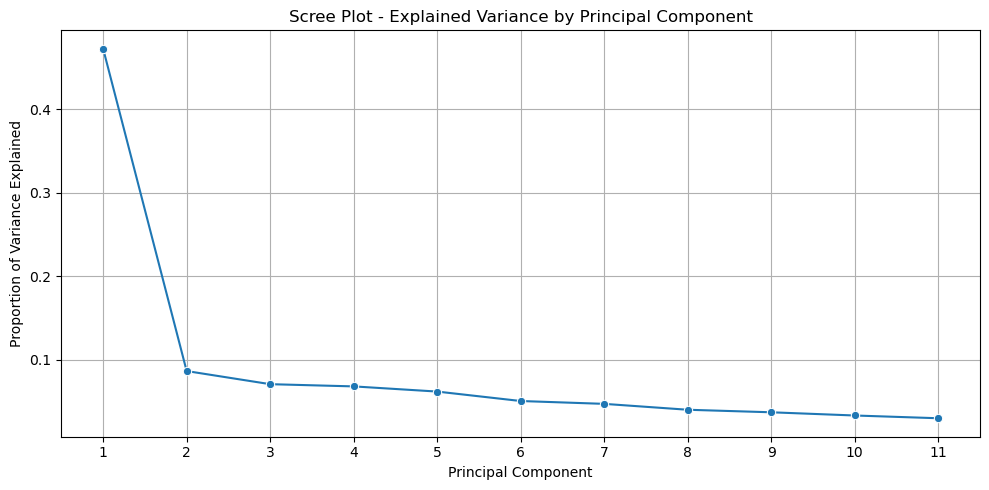

In [75]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_pickle(rf"{input_folder_path}\Main_Director_COMPLETE.pkl") # .loc[~pd.isnull(mainDirect["Skills/Competencies"])].

df = df.loc[ ~((df["govtdummy"] == 1) | (df["AsOnYear"] <= 2012)) ].reset_index(drop = True)



for col in cols:
    df[col] = df[col].astype(int)

df["skilllist_leadership_outside_board"] = (df["skilllist_leadership"] | df["Outside Board"]).astype(int)
skillset_cols = [
    #'skilllist_manufacturing_supply_chain',
    'skilllist_sustainability', #'skilllist_entrepreneurial', 'skilllist_compensation',
    'skilllist_governance', 'skilllist_international', #'skilllist_government_policy', 
    'skilllist_legal', 'skilllist_leadership',
    'skilllist_marketing', 'skilllist_risk_management',
    'skilllist_strategic_planning',
    'skilllist_technology', 'skilllist_hr', 
    'skilllist_finance_accounting'   
]


for col in skillset_cols:
    df[f'{col}_demeaned'] = df[col] - df.groupby('Symbol')[col].transform('mean')

# for col in skillset_cols:
#     df[f'{col}_demeaned'] = df[f'{col}_demeaned'] - df.groupby('AsOnYear')[col].transform('mean')

final_cols = [f'{col}_demeaned' for col in skillset_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[final_cols])

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# pca = PCA(n_components=1)
# principal_component = pca.fit_transform(X_scaled)
# df['SkillsetIndex'] = principal_component[:, 0]
# df['SkillsetIndex'] = (df['SkillsetIndex'] - df['SkillsetIndex'].mean()) / df['SkillsetIndex'].std()

# median_value = df['SkillsetIndex'].median()
# df['SkillsetGeneralistDummy'] = (df['SkillsetIndex'] > median_value).astype(int)


loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(skillset_cols))],
    index=final_cols
)

In [76]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings['PC1'].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))

Eigenvalue for PC1: 5.198
Explained Variance Ratio for PC1: 47.26%
Cumulative Explained Variance Ratio up to PC1: 47.26%

Top PC1 Loadings:
skilllist_governance_demeaned            0.355
skilllist_leadership_demeaned            0.344
skilllist_risk_management_demeaned       0.342
skilllist_legal_demeaned                 0.336
skilllist_strategic_planning_demeaned    0.333
skilllist_technology_demeaned            0.332
skilllist_finance_accounting_demeaned    0.300
skilllist_hr_demeaned                    0.250
skilllist_marketing_demeaned             0.245
skilllist_international_demeaned         0.221
skilllist_sustainability_demeaned        0.208
Name: PC1, dtype: float64


In [77]:
print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative expl variance = {cum_explained_variance:.2f}%")
        

PCs with eigen value and Explained Variance:
PC 1     : 5.198    ::: 47.26 %
PC 2     : 0.953    ::: 8.67 %
PC 3     : 0.781    ::: 7.10 %
PC 4     : 0.751    ::: 6.83 %
PC 5     : 0.683    ::: 6.21 %
PC 6     : 0.559    ::: 5.08 %
PC 7     : 0.521    ::: 4.74 %
PC 8     : 0.444    ::: 4.03 %
PC 9     : 0.410    ::: 3.73 %
PC 10    : 0.368    ::: 3.34 %
PC 11    : 0.332    ::: 3.02 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 1 PCs cumulative expl variance = 47.26%


In [78]:
df[skillset_cols].describe()

,skilllist_sustainability,skilllist_governance,skilllist_international,skilllist_legal,skilllist_leadership,skilllist_marketing,skilllist_risk_management,skilllist_strategic_planning,skilllist_technology,skilllist_hr,skilllist_finance_accounting
count,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000,170365.000000
mean,0.176996,0.555871,0.222563,0.481707,0.653121,0.580207,0.465013,0.577219,0.576280,0.258304,0.753013
std,0.381667,0.496870,0.415969,0.499667,0.475978,0.493526,0.498776,0.494003,0.494149,0.437703,0.431261
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---

---

---

# V1 : 2013 Onwards, ALL

In [72]:
pcaData = mainDirect[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","skilllist_manufacturing_supply_chain",
    "skilllist_sustainability", 
    "skilllist_governance", "skilllist_government_policy", "skilllist_international",
    "skilllist_leadership", "skilllist_legal",
    "skilllist_marketing", "skilllist_risk_management",
    "skilllist_strategic_planning", 
    "skilllist_hr", "skilllist_technology", "skilllist_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [73]:
"skilllist_scientific", "skilllist_entrepreneurial", "skilllist_compensation", "skilllist_conglomerate_experience",

('skilllist_scientific',
 'skilllist_entrepreneurial',
 'skilllist_compensation',
 'skilllist_conglomerate_experience')

In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

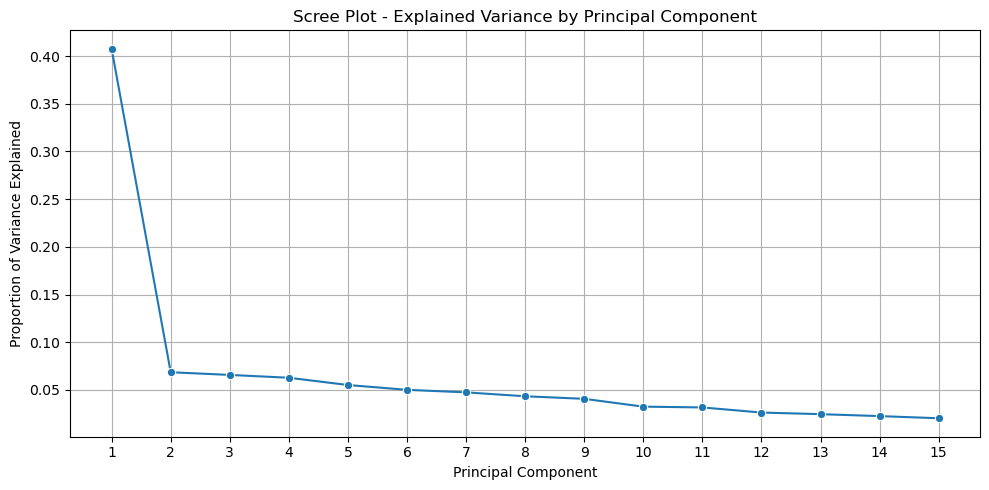

In [40]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_22224\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


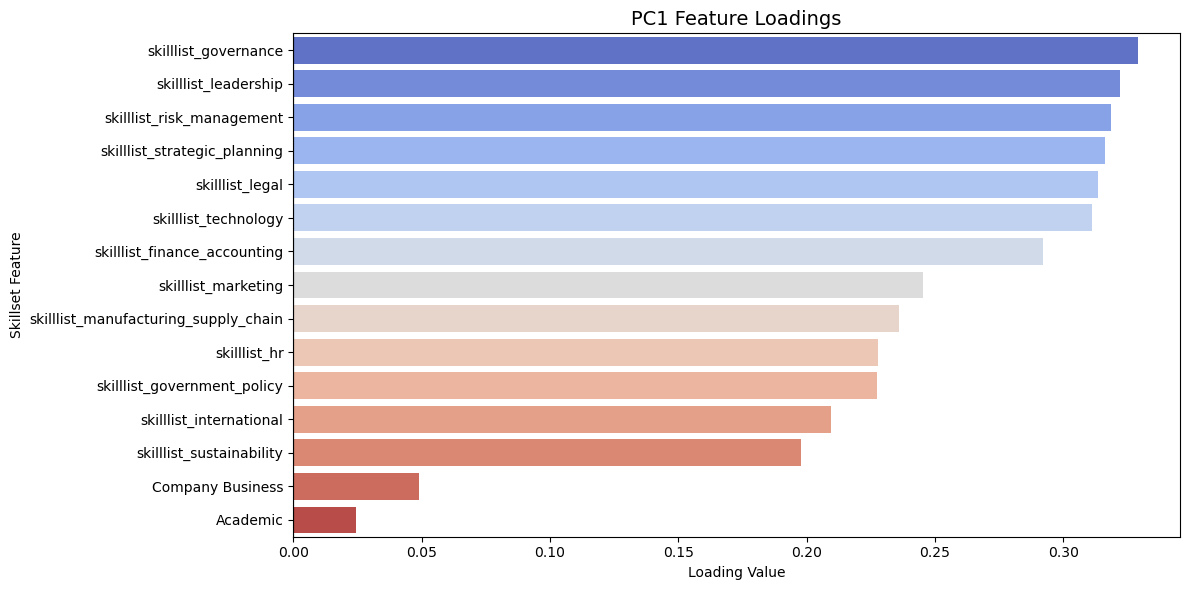

In [42]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [43]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 6.113
Explained Variance Ratio for PC1: 40.756%
Top PC1 Loadings for ALL data from 2013:

Academic                                 0.025
Company Business                         0.049
skilllist_sustainability                 0.198
skilllist_international                  0.209
skilllist_government_policy              0.228
skilllist_hr                             0.228
skilllist_manufacturing_supply_chain     0.236
skilllist_marketing                      0.246
skilllist_finance_accounting             0.292
skilllist_technology                     0.311
skilllist_legal                          0.313
skilllist_strategic_planning             0.316
skilllist_risk_management                0.319
skilllist_leadership                     0.322
skilllist_governance                     0.329


# V1 : 2013 Onwards, ALL

In [66]:
pcaData = mainDirect[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","committee_manufacturing_supply_chain",
    "committee_governance", "committee_international", "committee_legal",
    "committee_risk_management",
    "committee_strategic_planning", "committee_conglomerate_experience",
    "committee_technology", "committee_finance_accounting", "Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [67]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

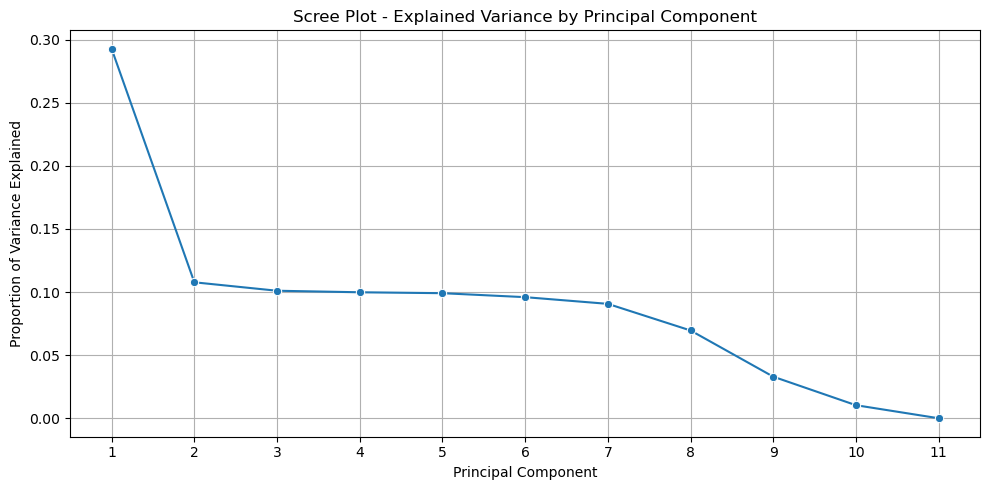

In [68]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_22224\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


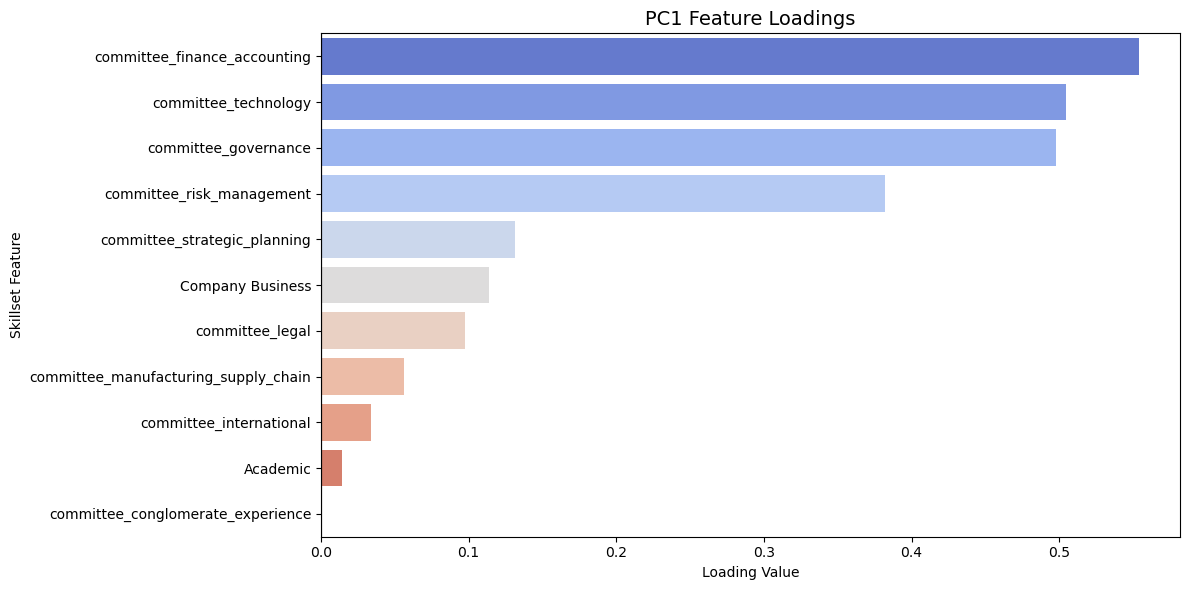

In [70]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [65]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 2.138
Explained Variance Ratio for PC1: 19.433%
Top PC1 Loadings for ALL data from 2013:

Company Business                         0.117
Academic                                 0.120
profile_conglomerate_experience          0.177
profile_legal                            0.185
profile_risk_management                  0.238
profile_manufacturing_supply_chain       0.281
profile_strategic_planning               0.285
profile_governance                       0.305
profile_international                    0.399
profile_technology                       0.461
profile_finance_accounting               0.473


# V2 : 2016 Onwards, ALL

In [75]:
pcaData = mainDirect.loc[mainDirect["AsOnYear"]>=2016].copy()

pcaData = pcaData[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","combined_manufacturing_supply_chain",
    "combined_sustainability", "combined_entrepreneurial", "combined_compensation",
    "combined_governance", "combined_government_policy", "combined_international",
    "combined_leadership_outside_board", "combined_legal",
    "combined_marketing", "combined_risk_management", "combined_scientific",
    "combined_strategic_planning", "combined_conglomerate_experience",
    "combined_hr", "combined_technology", "combined_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

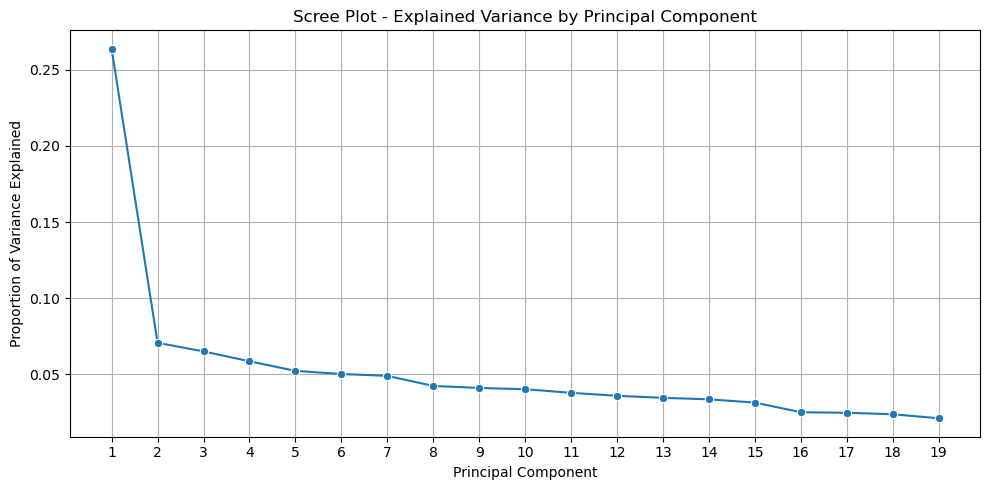

In [77]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

In [83]:
scaled_data_df = pd.DataFrame(data = scaled_data, columns = pcaData.columns)

In [84]:
scaled_data_df.describe()

,Academic,combined_manufacturing_supply_chain,combined_sustainability,combined_entrepreneurial,combined_compensation,combined_governance,combined_government_policy,combined_international,combined_leadership_outside_board,combined_legal,combined_marketing,combined_risk_management,combined_scientific,combined_strategic_planning,combined_conglomerate_experience,combined_hr,combined_technology,combined_finance_accounting,Company Business
count,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05
mean,5.787322e-17,1.668111e-16,-1.097889e-16,6.425630e-17,-1.140443e-16,1.319169e-16,2.127692e-17,6.957553e-17,-1.514917e-16,5.787322e-17,1.187252e-16,2.323440e-16,-5.521361e-17,2.212800e-17,5.659661e-17,5.489445e-17,-8.569279e-17,-1.334595e-16,-2.348972e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.640260e-01,-1.230763e+00,-9.616857e-01,-9.272949e-01,-9.342567e-01,-1.705224e+00,-7.191753e-01,-8.630037e-01,-1.922605e+00,-1.079104e+00,-1.291479e+00,-1.171654e+00,-2.638150e-01,-1.306588e+00,-1.896567e-01,-9.553598e-01,-4.807485e+00,-3.875893e+00,-2.317141e+00
25%,-2.640260e-01,-1.230763e+00,-9.616857e-01,-9.272949e-01,-9.342567e-01,-1.705224e+00,-7.191753e-01,-8.630037e-01,5.201276e-01,-1.079104e+00,-1.291479e+00,-1.171654e+00,-2.638150e-01,-1.306588e+00,-1.896567e-01,-9.553598e-01,2.080090e-01,2.580050e-01,4.315664e-01
50%,-2.640260e-01,8.125039e-01,-9.616857e-01,-9.272949e-01,-9.342567e-01,5.864331e-01,-7.191753e-01,-8.630037e-01,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,-2.638150e-01,7.653522e-01,-1.896567e-01,-9.553598e-01,2.080090e-01,2.580050e-01,4.315664e-01
75%,-2.640260e-01,8.125039e-01,1.039841e+00,1.078406e+00,1.070370e+00,5.864331e-01,1.390481e+00,1.158744e+00,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,-2.638150e-01,7.653522e-01,-1.896567e-01,1.046726e+00,2.080090e-01,2.580050e-01,4.315664e-01
max,3.787506e+00,8.125039e-01,1.039841e+00,1.078406e+00,1.070370e+00,5.864331e-01,1.390481e+00,1.158744e+00,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,3.790535e+00,7.653522e-01,5.272685e+00,1.046726e+00,2.080090e-01,2.580050e-01,4.315664e-01


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26540\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


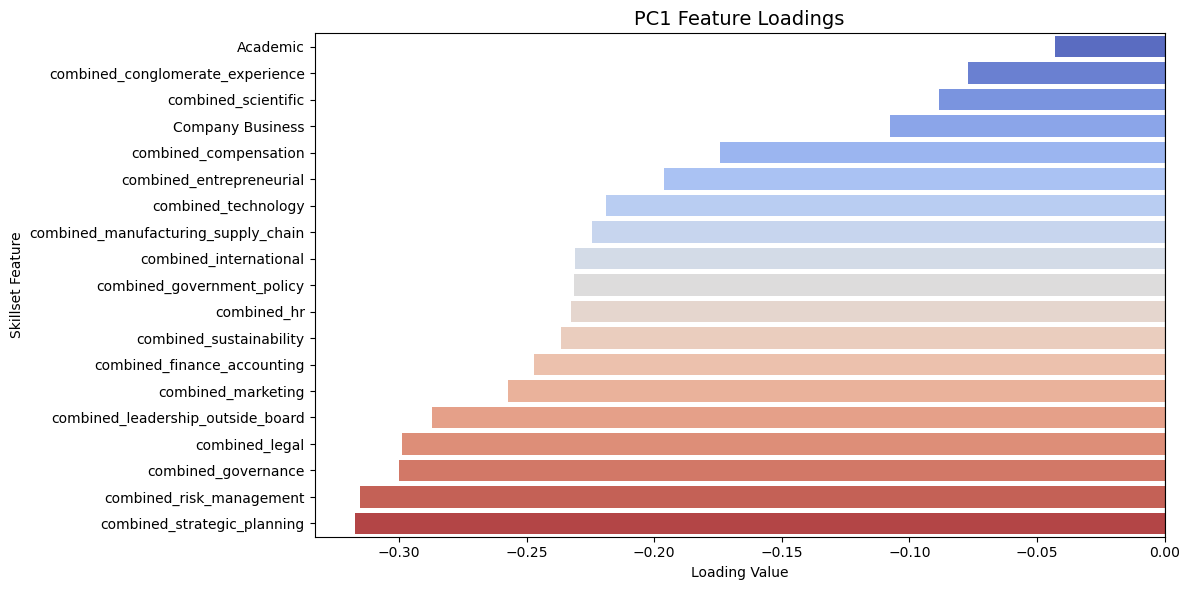

In [36]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [37]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 5.013
Explained Variance Ratio for PC1: 26.383%
Top PC1 Loadings for ALL data from 2013:

combined_strategic_planning              -0.317
combined_risk_management                 -0.315
combined_governance                      -0.300
combined_legal                           -0.299
combined_leadership_outside_board        -0.287
combined_marketing                       -0.257
combined_finance_accounting              -0.247
combined_sustainability                  -0.237
combined_hr                              -0.232
combined_government_policy               -0.231
combined_international                   -0.231
combined_manufacturing_supply_chain      -0.225
combined_technology                      -0.219
combined_entrepreneurial                 -0.196
combined_compensation                    -0.174
Company Business                         -0.108
combined_scientific                      -0.088
combined_conglomerate_experience         -0.077
Academic                  

# V2 : 2016 Onwards, ALL

In [85]:
pcaData = mainDirect.loc[mainDirect["AsOnYear"]>=2016].copy()

pcaData = pcaData[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","combined_manufacturing_supply_chain",
    "combined_sustainability", "combined_entrepreneurial", "combined_compensation",
    "combined_governance", "combined_government_policy", "combined_international",
    "combined_leadership_outside_board", "combined_legal",
    "combined_marketing", "combined_risk_management", "combined_scientific",
    "combined_strategic_planning", "combined_conglomerate_experience",
    "combined_hr", "combined_technology", "combined_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [86]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = pcaData

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

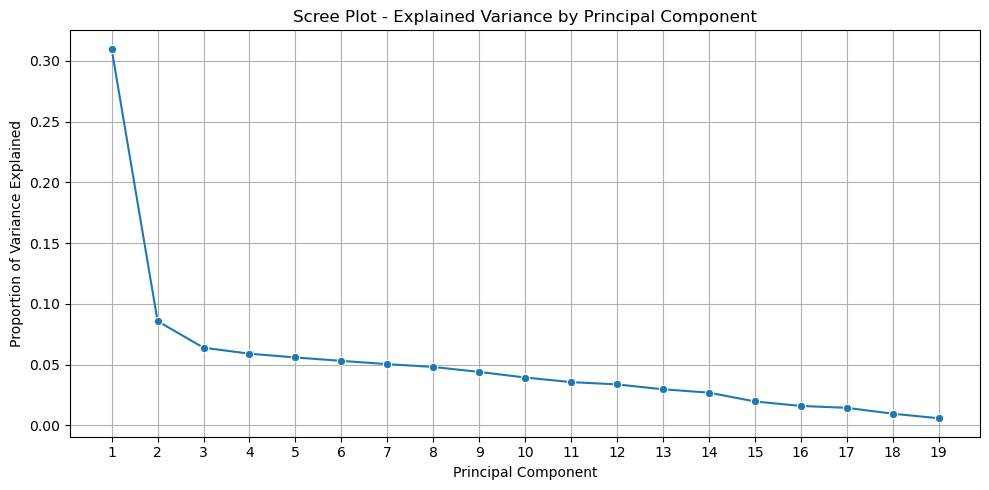

In [87]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [88]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

In [89]:
scaled_data_df = pd.DataFrame(data = scaled_data, columns = pcaData.columns)

In [90]:
scaled_data_df.describe()

,Academic,combined_manufacturing_supply_chain,combined_sustainability,combined_entrepreneurial,combined_compensation,combined_governance,combined_government_policy,combined_international,combined_leadership_outside_board,combined_legal,combined_marketing,combined_risk_management,combined_scientific,combined_strategic_planning,combined_conglomerate_experience,combined_hr,combined_technology,combined_finance_accounting,Company Business
count,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05,1.335800e+05
mean,5.787322e-17,1.668111e-16,-1.097889e-16,6.425630e-17,-1.140443e-16,1.319169e-16,2.127692e-17,6.957553e-17,-1.514917e-16,5.787322e-17,1.187252e-16,2.323440e-16,-5.521361e-17,2.212800e-17,5.659661e-17,5.489445e-17,-8.569279e-17,-1.334595e-16,-2.348972e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.640260e-01,-1.230763e+00,-9.616857e-01,-9.272949e-01,-9.342567e-01,-1.705224e+00,-7.191753e-01,-8.630037e-01,-1.922605e+00,-1.079104e+00,-1.291479e+00,-1.171654e+00,-2.638150e-01,-1.306588e+00,-1.896567e-01,-9.553598e-01,-4.807485e+00,-3.875893e+00,-2.317141e+00
25%,-2.640260e-01,-1.230763e+00,-9.616857e-01,-9.272949e-01,-9.342567e-01,-1.705224e+00,-7.191753e-01,-8.630037e-01,5.201276e-01,-1.079104e+00,-1.291479e+00,-1.171654e+00,-2.638150e-01,-1.306588e+00,-1.896567e-01,-9.553598e-01,2.080090e-01,2.580050e-01,4.315664e-01
50%,-2.640260e-01,8.125039e-01,-9.616857e-01,-9.272949e-01,-9.342567e-01,5.864331e-01,-7.191753e-01,-8.630037e-01,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,-2.638150e-01,7.653522e-01,-1.896567e-01,-9.553598e-01,2.080090e-01,2.580050e-01,4.315664e-01
75%,-2.640260e-01,8.125039e-01,1.039841e+00,1.078406e+00,1.070370e+00,5.864331e-01,1.390481e+00,1.158744e+00,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,-2.638150e-01,7.653522e-01,-1.896567e-01,1.046726e+00,2.080090e-01,2.580050e-01,4.315664e-01
max,3.787506e+00,8.125039e-01,1.039841e+00,1.078406e+00,1.070370e+00,5.864331e-01,1.390481e+00,1.158744e+00,5.201276e-01,9.266946e-01,7.743060e-01,8.534943e-01,3.790535e+00,7.653522e-01,5.272685e+00,1.046726e+00,2.080090e-01,2.580050e-01,4.315664e-01


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_22224\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


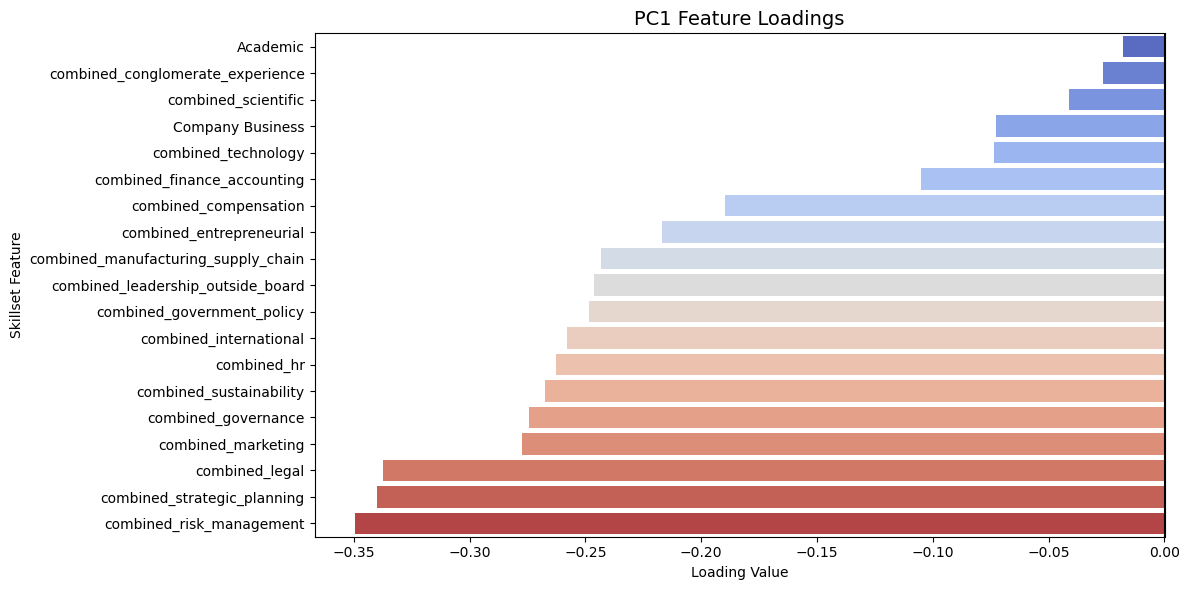

In [91]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [92]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 5.013
Explained Variance Ratio for PC1: 26.383%
Top PC1 Loadings for ALL data from 2013:

combined_risk_management                 -0.349
combined_strategic_planning              -0.340
combined_legal                           -0.338
combined_marketing                       -0.277
combined_governance                      -0.274
combined_sustainability                  -0.267
combined_hr                              -0.263
combined_international                   -0.258
combined_government_policy               -0.248
combined_leadership_outside_board        -0.246
combined_manufacturing_supply_chain      -0.243
combined_entrepreneurial                 -0.217
combined_compensation                    -0.190
combined_finance_accounting              -0.105
combined_technology                      -0.074
Company Business                         -0.073
combined_scientific                      -0.041
combined_conglomerate_experience         -0.027
Academic                  

# V3 : 2013 Onwards, Only Skill List and Profile

In [38]:
mainDirect1 = mainDirect.copy()

skills = ["manufacturing_supply_chain",
          "sustainability", "entrepreneurial", "compensation",
          "governance", "government_policy", "international",
          "leadership", "legal",
          "marketing", "risk_management", "scientific",
          "strategic_planning", "conglomerate_experience",
          "hr", "technology", "finance_accounting"]

for skill in skills:
    mainDirect1[f"skill_profile_{skill}"] = (mainDirect1[f"skilllist_{skill}"] | mainDirect1[f"profile_{skill}"]).astype(int)

mainDirect1["skill_profile_leadership_outside_board"] = (mainDirect1["skill_profile_leadership"] | mainDirect["Outside Board"]).astype(int)

In [39]:

pcaData = mainDirect1[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","skill_profile_manufacturing_supply_chain",
    "skill_profile_sustainability", "skill_profile_entrepreneurial", "skill_profile_compensation",
    "skill_profile_governance", "skill_profile_government_policy", "skill_profile_international",
    "skill_profile_leadership_outside_board", "skill_profile_legal",
    "skill_profile_marketing", "skill_profile_risk_management", "skill_profile_scientific",
    "skill_profile_strategic_planning", "skill_profile_conglomerate_experience",
    "skill_profile_hr", "skill_profile_technology", "skill_profile_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

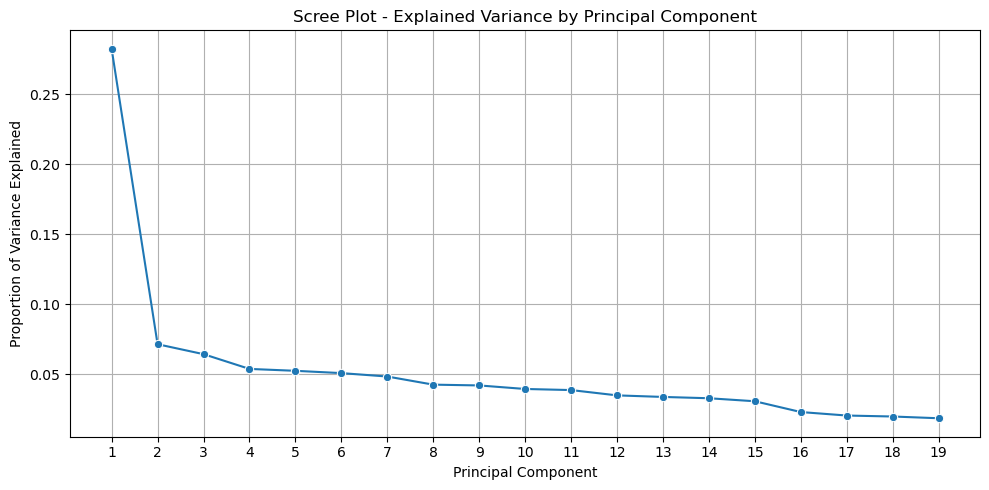

In [41]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26540\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


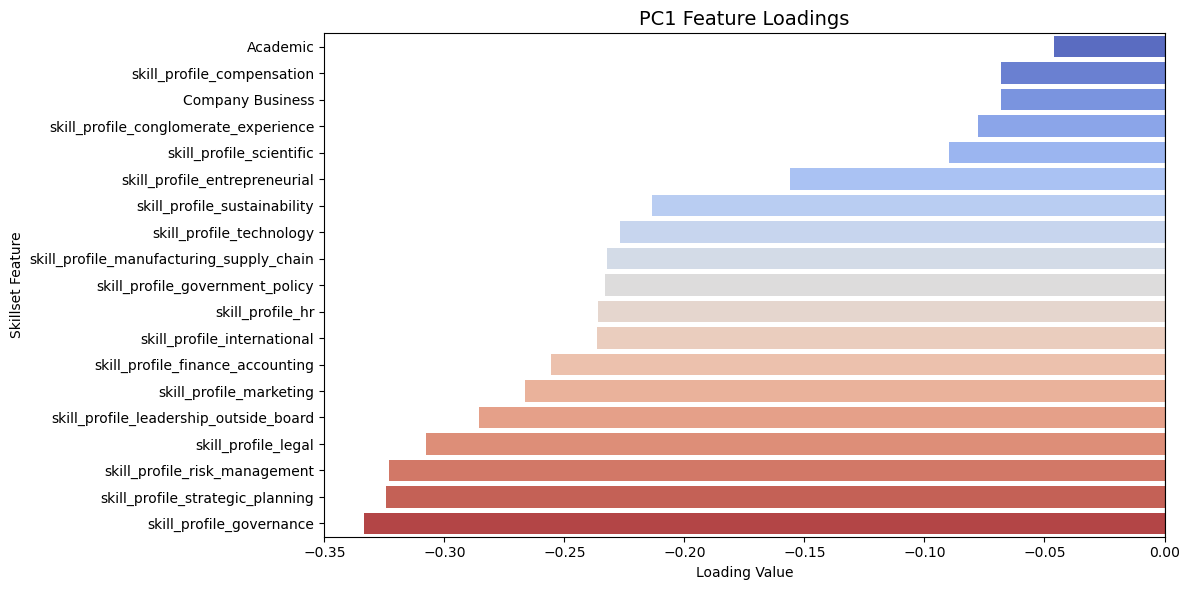

In [43]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [44]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 5.364
Explained Variance Ratio for PC1: 28.230%
Top PC1 Loadings for ALL data from 2013:

skill_profile_governance                 -0.333
skill_profile_strategic_planning         -0.324
skill_profile_risk_management            -0.323
skill_profile_legal                      -0.308
skill_profile_leadership_outside_board   -0.286
skill_profile_marketing                  -0.266
skill_profile_finance_accounting         -0.256
skill_profile_international              -0.236
skill_profile_hr                         -0.236
skill_profile_government_policy          -0.233
skill_profile_manufacturing_supply_chain -0.232
skill_profile_technology                 -0.227
skill_profile_sustainability             -0.213
skill_profile_entrepreneurial            -0.156
skill_profile_scientific                 -0.090
skill_profile_conglomerate_experience    -0.078
Company Business                         -0.068
skill_profile_compensation               -0.068
Academic                  

# V4 : 2013 Onwards, ALL, Removing all directors, who don't have any entrees

In [45]:
pcaData = mainDirect[~(pd.isnull(mainDirect["Skills/Competencies"]) & 
                       pd.isnull(mainDirect["Brief Profile"]) &
                       pd.isnull(mainDirect["Committee Name"]))].copy()

pcaData = pcaData[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","combined_manufacturing_supply_chain",
    "combined_sustainability", "combined_entrepreneurial", "combined_compensation",
    "combined_governance", "combined_government_policy", "combined_international",
    "combined_leadership_outside_board", "combined_legal",
    "combined_marketing", "combined_risk_management", "combined_scientific",
    "combined_strategic_planning", "combined_conglomerate_experience",
    "combined_hr", "combined_technology", "combined_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [46]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

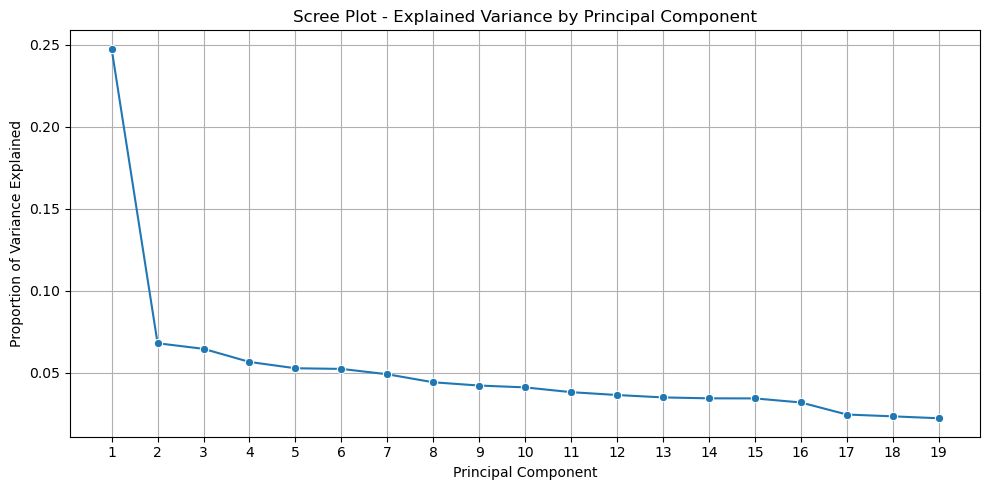

In [47]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26540\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


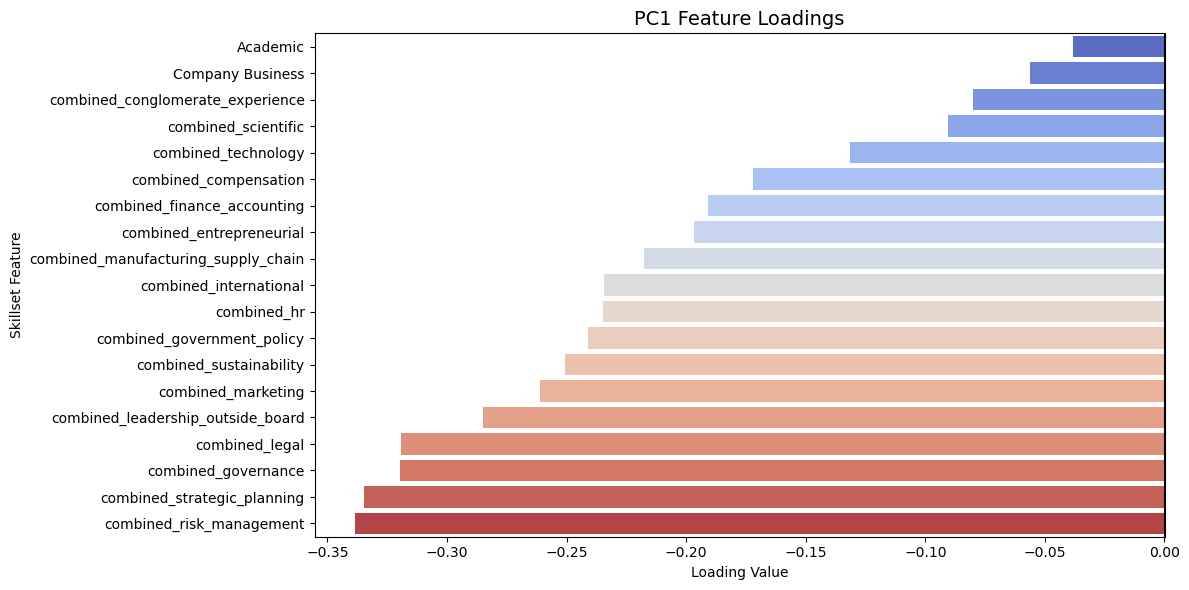

In [49]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [50]:
print(f"Filtered out: {len(mainDirect) - len(pcaData)}\n")

print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Filtered out: 7543

Eigenvalue for PC1: 4.704
Explained Variance Ratio for PC1: 24.760%
Top PC1 Loadings for ALL data from 2013:

combined_risk_management                 -0.338
combined_strategic_planning              -0.335
combined_governance                      -0.320
combined_legal                           -0.319
combined_leadership_outside_board        -0.285
combined_marketing                       -0.261
combined_sustainability                  -0.251
combined_government_policy               -0.241
combined_hr                              -0.235
combined_international                   -0.234
combined_manufacturing_supply_chain      -0.218
combined_entrepreneurial                 -0.197
combined_finance_accounting              -0.191
combined_compensation                    -0.172
combined_technology                      -0.132
combined_scientific                      -0.091
combined_conglomerate_experience         -0.080
Company Business                         -0.056
Academ

## 5 Merge with Main 6

In [ ]:
# mainDirect8 = mainDirect7.merge(scaledData, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
# mainDirect9 = mainDirect8.merge(pcaOutput, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")

# mainDirect10 = mainDirect9.merge(scaledData2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "left")
# mainDirect11 = mainDirect10.merge(pcaOutput2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "left")

---

---

---

---

---

## Obsolete code

In [ ]:
# pcaOutputNonScaled = pd.DataFrame(data = pca_data, index = pcaData.index)\
# .rename({0:"PCA1"}, axis = 1).reset_index(drop = False)

# pcaOutputScaled = pd.DataFrame(data = pca_data_scaled, index = pcaData.index)\
# .rename({0:"PCA1_scaled"}, axis = 1).reset_index(drop = False)

# pcaOutput = pcaOutputNonScaled.merge(pcaOutputScaled, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
# pcaOutput

# explained_variance = pca.explained_variance_ratio_
# explained_variance

# pcaOutput["FactorLoading1"] = eigenvectors[0, 0]
# pcaOutput["FactorLoading2"] = eigenvectors[0, 1]
# pcaOutput["FactorLoading3"] = eigenvectors[0, 2]
# pcaOutput["FactorLoading4"] = eigenvectors[0, 3]
# pcaOutput["FactorLoading5"] = eigenvectors[0, 4]

# pcaOutput["FactorLoading6"] = eigenvectors[0, 5]
# pcaOutput["FactorLoading7"] = eigenvectors[0, 6]
# pcaOutput["FactorLoading8"] = eigenvectors[0, 7]
# pcaOutput["FactorLoading9"] = eigenvectors[0, 8]
# pcaOutput["FactorLoading10"] = eigenvectors[0, 9]

# pcaOutput["FactorLoading11"] = eigenvectors[0, 10]
# pcaOutput["FactorLoading12"] = eigenvectors[0, 11]
# pcaOutput["FactorLoading13"] = eigenvectors[0, 12]
# pcaOutput["FactorLoading14"] = eigenvectors[0, 13]
# pcaOutput["FactorLoading15"] = eigenvectors[0, 14]

# pcaOutput["FactorLoading16"] = eigenvectors[0, 15]
# pcaOutput["FactorLoading17"] = eigenvectors[0, 16]
# pcaOutput["FactorLoading18"] = eigenvectors[0, 17]
# pcaOutput["FactorLoading19"] = eigenvectors[0, 18]
# pcaOutput["FactorLoading20"] = eigenvectors[0, 19]

# pcaOutput["Eigenvalue"] = eigenvalues[0]

# scaledData = pd.DataFrame(data = scaled_data, index = pcaData.index)\
# .rename({0:"NumSkillsScaled", 1:"NumFirmsPastScaled", 2:"NumIndustryPastScaled", 3:"HasCeoMDChairXPScaled", 4:"HasConglomerateXPScaled"}, axis = 1)\
# .reset_index(drop = False)
# scaledData

In [ ]:
## Unscaled PCA - the inputs here are unscaled, but hthis is wrong, preserving code for idk what

# pcaData = mainDirect7[[
#     'Person Code', 'Symbol', 'AsOnDate',
#     'Academic','combined_manufacturing_supply_chain','Outside Board',
#     'combined_sustainability', 'combined_entrepreneurial', 'combined_compensation',
#     'combined_governance', 'combined_government_policy', 'combined_international',
#     'combined_leadership', 'combined_legal',
#     'combined_marketing', 'combined_risk_management', 'combined_scientific',
#     'combined_strategic_planning', 'combined_conglomerate_experience',
#     'combined_hr', 'combined_technology', 'combined_finance_accounting','Company Business' ]].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

# scaled_data = pcaData
# pca = PCA(n_components = 2)
# pca.fit(scaled_data)
# pca_data = pca.transform(scaled_data)

# pca_data_scaled = preprocessing.scale(pca_data)


# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

# pcaOutputNonScaled = pd.DataFrame(data = pca_data, index = pcaData.index)\
# .rename({0:"General Ability Index"}, axis = 1).reset_index(drop = False)

# pcaOutputScaled = pd.DataFrame(data = pca_data_scaled, index = pcaData.index)\
# .rename({0:"General Ability Index_scaled"}, axis = 1).reset_index(drop = False)

# pcaOutput = pcaOutputNonScaled.merge(pcaOutputScaled, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
# pcaOutput

# explained_variance = pca.explained_variance_ratio_
# explained_variance

# pcaOutput["General Ability Index"].var()

# pcaOutput["FactorLoading1"] = eigenvectors[0, 0]
# pcaOutput["FactorLoading2"] = eigenvectors[0, 1]
# pcaOutput["FactorLoading3"] = eigenvectors[0, 2]
# pcaOutput["FactorLoading4"] = eigenvectors[0, 3]
# pcaOutput["FactorLoading5"] = eigenvectors[0, 4]

# pcaOutput["FactorLoading6"] = eigenvectors[0, 5]
# pcaOutput["FactorLoading7"] = eigenvectors[0, 6]
# pcaOutput["FactorLoading8"] = eigenvectors[0, 7]
# pcaOutput["FactorLoading9"] = eigenvectors[0, 8]
# pcaOutput["FactorLoading10"] = eigenvectors[0, 9]

# pcaOutput["FactorLoading11"] = eigenvectors[0, 10]
# pcaOutput["FactorLoading12"] = eigenvectors[0, 11]
# pcaOutput["FactorLoading13"] = eigenvectors[0, 12]
# pcaOutput["FactorLoading14"] = eigenvectors[0, 13]
# pcaOutput["FactorLoading15"] = eigenvectors[0, 14]

# pcaOutput["FactorLoading16"] = eigenvectors[0, 15]
# pcaOutput["FactorLoading17"] = eigenvectors[0, 16]
# pcaOutput["FactorLoading18"] = eigenvectors[0, 17]
# pcaOutput["FactorLoading19"] = eigenvectors[0, 18]
# pcaOutput["FactorLoading20"] = eigenvectors[0, 19]

# pcaOutput["Eigenvalue"] = eigenvalues[0]

# scaledData = pd.DataFrame(data = scaled_data, index = pcaData.index)\
# .rename({0:"NumSkillsScaled", 1:"NumFirmsPastScaled", 2:"NumIndustryPastScaled", 3:"HasCeoMDChairXPScaled", 4:"HasConglomerateXPScaled"}, axis = 1)\
# .reset_index(drop = False)
# scaledData

In [ ]:
### PCA for only 2013 and onwards - OBSOLETE, ABOVE DATA IS ALREADY FILTERED

# pcaData2013 = mainDirect7.loc[ mainDirect7["AsOnDate"] >= "2013-01-01",
# ["Person Code", "Symbol", "AsOnDate", "NumSkills", "NumFirmsPast", "NumIndustryPast", "HasCeoMDChairXP", "HasConglomerateXP"]].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

# scaled_data2013 = preprocessing.scale(pcaData2013)
# pca2013 = PCA(n_components = 1)
# pca2013.fit(scaled_data2013)
# pca_data2013 = pca2013.transform(scaled_data2013)

# pca_data_scaled2013 = preprocessing.scale(pca_data2013)

# eigenvalues2013 = pca2013.explained_variance_
# eigenvectors2013 = pca2013.components_

# pcaOutputNonScaled2013 = pd.DataFrame(data = pca_data2013, index = pcaData2013.index)\
# .rename({0:"General Ability Index_2013"}, axis = 1).reset_index(drop = False)

# pcaOutputScaled2013 = pd.DataFrame(data = pca_data_scaled2013, index = pcaData2013.index)\
# .rename({0:"General Ability Index_scaled_2013"}, axis = 1).reset_index(drop = False)

# pcaOutput2013 = pcaOutputNonScaled2013.merge(pcaOutputScaled2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
# pcaOutput2013

# pcaOutput2013["FactorLoading1_2013"] = eigenvectors[0, 0]
# pcaOutput2013["FactorLoading2_2013"] = eigenvectors[0, 1]
# pcaOutput2013["FactorLoading3_2013"] = eigenvectors[0, 2]
# pcaOutput2013["FactorLoading4_2013"] = eigenvectors[0, 3]
# pcaOutput2013["FactorLoading5_2013"] = eigenvectors[0, 4]

# pcaOutput2013["Eigenvalue2013"] = eigenvalues[0]

# scaledData2013 = pd.DataFrame(data = scaled_data2013, index = pcaData2013.index)\
# .rename({0:"NumSkillsScaled_2013", 1:"NumFirmsPastScaled_2013", 2:"NumIndustryPastScaled_2013", 3:"HasCeoMDChairXPScaled_2013", 4:"HasConglomerateXPScaled_2013"}, axis = 1)\
# .reset_index(drop = False)
# scaledData2013